# Práctica 3 PVC
### Natalia Martínez García y Lucía Vega Navarrete - Grupo 1.1

In [11]:
import numpy as np
from pathlib import Path
from skimage import io
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
from skimage.morphology import binary_opening, binary_closing, disk, remove_small_objects, remove_small_holes
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter, sobel
from skimage.filters import frangi

In [12]:
# Fijamos la semilla para poder reproducir los resultados
import random
seed = 123
np.random.seed(seed)
random.seed(seed)

## Ejercicio 1 -  Segmentación de carreteras en imagen aérea de alta resolución

### Carga del dataset

Primero cargamos todas las imágenes de satélite y sus máscaras correspondientes desde las carpetas del dataset. Para garantizar que cada imagen está emparejada con su máscara correcta, primero se listan y ordenan los archivos. Después, las imágenes se leen tal cual y las máscaras se binarizan para obtener valores 0/1. Luego, todo se convierte en arrays NumPy para poder procesarlo de forma eficiente en los siguientes pasos de la práctica. Por último, imprimimos las dimensiones de las imágenes para comprobar que todo se ha cargado correctamente. 

In [13]:
# Ruta al dataset
# Lo tenemos en la misma carpeta que el notebook
dataset_path = Path("DataSet_1/roads")
sat_path = dataset_path / "sat" # Carpeta con las imagenes por satelite (inputs del modelo)
gt_path = dataset_path / "gt" # Carpeta con las carreteras marcadas (salidas esperadas)

# Cargar las imágenes
# Las ordenamos para que cada imagen de la carpeta sat este en la misma posicion que en la carpeta gt (tienen el mismo nombre)
sat_files = sorted(sat_path.glob("*.tif*")) # Leer todas las de la carpeta a la vez
gt_files = sorted(gt_path.glob("*.tif*"))

# Listas donde almacenamos las imágenes y sus máscaras ya cargadas
images = []
masks = []

# Recorremos ambas listas en parallelo
for sat_file, gt_file in zip(sat_files, gt_files):
    # Cargar imagen RGB del satelite
    img = io.imread(sat_file)
    images.append(img)
    
    # Cargar y preparar la máscara
    mask = io.imread(gt_file) # La máscara suele venir en escala de grises con valores 0 (fondo) y 255 (carretera)
    mask = (mask > 128).astype(np.uint8) # Lo tenemos que poner convertir a binario (0 y 1) porque ahora tiene como valores 0 y 255
    masks.append(mask)
    
# Convertimos las listas a arrays numpy para poder indexarlas 
images = np.array(images)
masks = np.array(masks)

# Comprobamos las dimensiones
print(f"Shape imágenes: {images.shape}")
print(f"Shape máscaras: {masks.shape}")

Shape imágenes: (20, 1500, 1500, 3)
Shape máscaras: (20, 1500, 1500)


La salida confirma que el dataset se ha cargado correctamente: tenemos 20 imágenes y 20 máscaras, todas con un tamaño uniforme de 1500×1500 píxeles. Las imágenes son RGB (por eso tienen 3 canales) y las máscaras están en formato binario de una sola capa. Esto indica que el procesamiento previo funcionó como se esperaba y que los datos están listos para continuar con el preprocesado y el diseño del método de segmentación.

### División de los datos

Aquí hacemos una división aleatoria del dataset en entrenamiento, validación y test. Para ello, primero generamos una permutación aleatoria de los índices de todas las imágenes, asegurando que la selección no siga ningún patrón del orden original. A partir de esa lista mezclada, se toman 2 imágenes para test, 2 para validación y el resto para entrenamiento. Después, se usan esos índices para extraer las imágenes y máscaras correspondientes, obteniendo así tres subconjuntos diferenciados que se utilizarán para entrenar, ajustar y evaluar el método de segmentación.

In [14]:
# Dividimos aleatoriamente
n_total = len(images) 
indices = np.random.permutation(n_total) # Devuelve una secuencia desordenada de numeros del 0 a n_total - 1

# Dividimos el dataset por indices
test_indices = indices[:2] # 2 primeras para test
val_indices = indices[2:4] # 2 siguientes para val
train_indices = indices[4:] # resto para train

# Construimos cada subconjunto 
X_test = images[test_indices]
y_test = masks[test_indices]

X_val = images[val_indices]
y_val = masks[val_indices]

X_train = images[train_indices]
y_train = masks[train_indices]

# Comprobamos cuántas imágenes contiene cada partición
print(f"Train: {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")
print(f"Test: {len(X_test)} imágenes")

Train: 16 imágenes
Validación: 2 imágenes
Test: 2 imágenes


La salida muestra que la división se realizó correctamente: 16 imágenes para entrenar, 2 para validar y 2 para test. Esta distribución es coherente con el tamaño del dataset y permite disponer de suficientes ejemplos para entrenar un modelo básico, reservando al mismo tiempo datos independientes para comprobar el rendimiento y evitar sobreajuste. Esto confirma que la partición aleatoria ha funcionado como se esperaba y los conjuntos están listos para los siguientes pasos.

### Preprocesado

In [108]:
def normalize_images(images):
    """Normaliza imágenes al rango [0, 1]"""
    return images.astype(np.float32) / 255.0

def flatten_data(X, y):
    """Aplana los datos"""
    X_flat = X.reshape(-1, X.shape[-1])
    y_flat = y.reshape(-1)
    return X_flat, y_flat

def undersample(image, mask):
    """Balancea datos para tener igual cantidad de cada clase"""
    # Obtenemos los índices donde la máscara es carretera (1) y fondo (0).
    # Como el mapa ya está aplanado, son índices directos en un vector 1D.
    road_idx = np.where(mask == 1)[0]
    bg_idx = np.where(mask == 0)[0]
    
    # Igualamos el nº de píxeles de cada clase
    n_road = len(road_idx)
    bg_sampled = np.random.choice(bg_idx, n_road, replace=False)

    # Mezclamos
    selected = np.concatenate([road_idx, bg_sampled])
    np.random.shuffle(selected)

    return image[selected], mask[selected]

In [ ]:
def extract_features(image, window_size=7):
    """
    Extrae las características de una imagen normalizada.
    Devuelve un tensor (H, W, num_features).
    """
    features = []
    # HSV
    hsv = rgb2hsv(image)
    features.append(hsv[:, :, 0])   
    features.append(hsv[:, :, 1])    
    features.append(hsv[:, :, 2])   

    # TEXTURA LOCAL (media)
    for c in range(image.shape[2]):
        m = uniform_filter(image[:, :, c], size=window_size)
        features.append(m)

    # TEXTURA LOCAL (desviación estándar)
    for c in range(image.shape[2]):
        ch = image[:, :, c]
        mean = uniform_filter(ch, size=window_size)
        mean_sq = uniform_filter(ch**2, size=window_size)
        std = np.sqrt(np.maximum(mean_sq - mean**2, 0))
        features.append(std)


    # DETECCIÓN DE LÍNEAS (FRANGI)
    gray = np.mean(image, axis=2)
    sigmas_fine = [1, 2, 3]
    frangi_light = frangi(gray, sigmas=sigmas_fine, black_ridges=False)
    features.append(frangi_light)
    frangi_dark = frangi(gray, sigmas=sigmas_fine, black_ridges=True)
    features.append(frangi_dark)

    # GRADIENTE (BORDES)
    gx = sobel(gray, axis=1)
    gy = sobel(gray, axis=0)
    magnitud = np.sqrt(gx**2 + gy**2)
    features.append(magnitud)

    return np.dstack(features)

def extract_all_features(extract_features_function, images):
    """Extrae características para todas las imágenes""" 
    all_features = []
    for img in images:   
        features = extract_features_function(img)
        all_features.append(features)
    return np.array(all_features)


In [ ]:
def prepare_pixel_dataset(X, y, feature_type="raw", balance_train=False):
    """
    Convierte un conjunto (X, y) de imágenes en un dataset de píxeles.
    
    feature_type:
      - 'raw'→ solo color normalizado
      - 'color → más características

    balance_train: Si es True, aplica undersampling (para conjuntos de entrenamiento).
    """
    X_norm = normalize_images(X)
    
    if feature_type == "raw":
        X_feat = X_norm
    elif feature_type == "color":
        # Extraer mapas de características
        X_feat = extract_all_features(extract_features, X_norm)   
        """X_reshaped = X_feat.reshape(-1, X_feat.shape[-1])  
        mins = X_reshaped.min(axis=0)
        maxs = X_reshaped.max(axis=0)
        X_feat = (X_feat - mins) / ((maxs - mins) + 1e-8)"""

    X_flat, y_flat = flatten_data(X_feat, y)
    
    if balance_train:
        X_flat, y_flat = undersample(X_flat, y_flat)
    
    # Devolvemos también X_feat por si queremos reconstruir imágenes
    return X_flat, y_flat, X_feat

def print_dataset_info(X, y, X_flat, y_flat, title):
    print(f"\n=== {title} ===")
    print(f"Rango sin normalizar:{X.min():.2f}-{X.max():.2f}")
    print(f"Rango normalizado: {X_flat.min():.2f}-{X_flat.max():.2f}")
    print(f"Tamaño aplanado: {X_flat.shape} ; {y_flat.shape}")


In [ ]:
def evaluate_split(y_true, y_pred, name="Validación"):
    """Imprime las métricas de cada conjunto de datos"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1} 

def train_and_evaluate_model(model, X_train_balanced, y_train_balanced, X_val_flat, y_val_pred, X_test_flat, y_test_pred, model_name="Modelo"):
    """  Entrena un modelo de clasificación pixel a pixel (sobre datos balanceados) y evalúa su rendimiento en validación y test."""
    print(f"\n=== {model_name}: ENTRENAMIENTO ===")
    print(f"Entrenando con {len(X_train_balanced)} píxeles balanceados...")
    model.fit(X_train_balanced, y_train_balanced)
    print("Modelo entrenado")

    print("\n=== VALIDACIÓN ===")
    y_val_pred = model.predict(X_val_flat)
    metrics_val = evaluate_split(y_val_flat, y_val_pred, name="Validación")

    print("\n=== TEST ===")
    y_test_pred = model.predict(X_test_flat)
    metrics_test = evaluate_split(y_test_flat, y_test_pred, name="Test")

    return model, y_val_pred, y_test_pred, metrics_val, metrics_test

In [ ]:
def show_example_prediction(X_val_img, y_val, y_val_pred_flat, title="Predicción"):
    """
    Muestra un ejemplo de segmentación en la primera imagen de validación.
    X_val_img: imágenes originales con shape (N,H,W,3)
    y_val: máscaras ground truth con shape (N,H,W)
    y_val_pred_flat: predicciones aplanadas (N*H*W,)
    """
    n, h, w = y_val.shape
    y_val_pred_img = y_val_pred_flat.reshape(n, h, w)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(X_val_img[0])
    axes[0].set_title("Imagen original")
    axes[0].axis("off")
    
    axes[1].imshow(y_val[0], cmap="gray")
    axes[1].set_title("Ground truth")
    axes[1].axis("off")
    
    axes[2].imshow(y_val_pred_img[0], cmap="gray")
    axes[2].set_title(title)
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

#### Prueba baseline usando solo RGB como características

In [ ]:
X_train_flat, y_train_flat, X_train_feat = prepare_pixel_dataset(X_train, y_train, feature_type="raw", balance_train=True)
print_dataset_info(X_train, y_train, X_train_flat, y_train_flat, "Train")


X_val_flat, y_val_flat, X_val_feat = prepare_pixel_dataset(X_val, y_val, feature_type="raw", balance_train=False)
print_dataset_info(X_val, y_val, X_val_flat, y_val_flat, "Val")


X_test_flat, y_test_flat, X_test_feat = prepare_pixel_dataset(X_test, y_test, feature_type="raw", balance_train=False)
print_dataset_info(X_test, y_test, X_test_flat, y_test_flat, "Test")



=== Train ===
Rango sin normalizar: 0.00-255.00
Rango normalizado:   0.00-1.00
Tamaño aplanado:     (2529114, 3) ; (2529114,)

=== Val ===
Rango sin normalizar: 0.00-255.00
Rango normalizado:   0.00-1.00
Tamaño aplanado:     (4500000, 3) ; (4500000,)

=== Test ===
Rango sin normalizar: 0.00-255.00
Rango normalizado:   0.00-1.00
Tamaño aplanado:     (4500000, 3) ; (4500000,)



=== RandomForest RGB: ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   17.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   59.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Modelo entrenado

=== VALIDACIÓN ===


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    6.6s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:   23.4s finished



Validación:
  Accuracy:  0.8195
  Precision: 0.2265
  Recall:    0.7818
  F1-Score:  0.3513

=== TEST ===


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    5.6s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:   20.6s finished



Test:
  Accuracy:  0.8297
  Precision: 0.1190
  Recall:    0.8402
  F1-Score:  0.2085


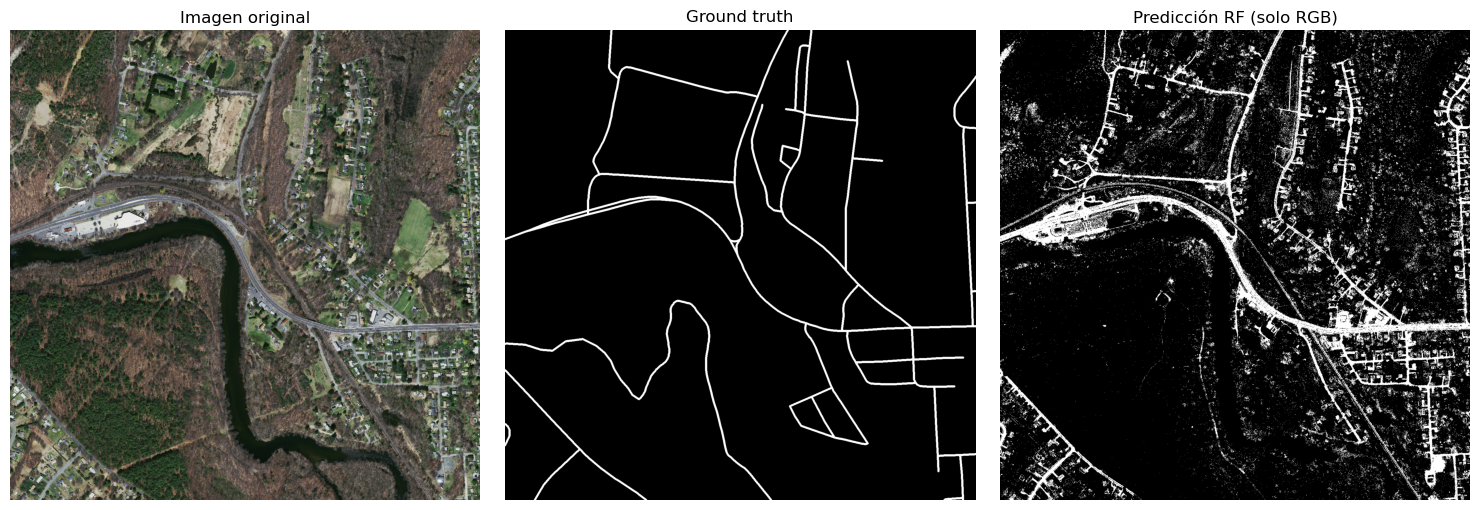

In [ ]:
# RANDOM FOREST
# Definimos el modelo.
rf_rgb = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=seed, n_jobs=-1, verbose=1)

# Lo entrenamos 
rf_rgb, y_val_pred_rgb, y_test_pred_rgb, metrics_val_rgb, metrics_test_rgb = train_and_evaluate_model(rf_rgb, X_train_balanced_rgb, y_train_balanced_rgb, X_val_flat_rgb, y_val_flat_rgb, 
                                                                                                      X_test_flat_rgb, y_test_flat_rgb, model_name="RandomForest RGB")

# Visualizamos 
show_example_prediction(X_val, y_val, y_val_pred_rgb, title="Predicción RF (solo RGB)")

PREGUNTA: LA EXTRACCIÓN DE CARACTERÍSTICAS SE HACE EN LOS 3 (TRAIN, TEST Y VALIDATION) O SOLO EN TRAIN?

el amigo me dijo esto: 
✅ 1. ¿La extracción de características se hace en train, val y test?

SÍ. En los tres.

Motivo:

El clasificador espera vectores de características tanto para entrenar como para predecir.

Si entrenas el modelo con RGB + HSV + Sobel + Frangi,
→ también necesitas esas mismas características en validación y test.

👉 La única diferencia es que el undersampling solo se hace en train.
Pero las características deben ser exactamente las mismas en los tres conjuntos.

#### Prueba con más características 

In [ ]:
X_train_col_flat, y_train_col_flat, _ = prepare_pixel_dataset(X_train, y_train, feature_type="color", balance_train=True)
print_dataset_info(X_train, y_train, X_train_col_flat, y_train_col_flat, "Train")

X_val_col_flat,   y_val_col_flat,   _ = prepare_pixel_dataset(X_val, y_val, feature_type="color", balance_train=False)
print_dataset_info(X_train, y_train, X_train_col_flat, y_train_col_flat, "Validación")

X_test_col_flat,  y_test_col_flat,  _ = prepare_pixel_dataset(X_test, y_test, feature_type="color", balance_train=False)
print_dataset_info(X_train, y_train, X_train_col_flat, y_train_col_flat, "Test")


=== Train ===
Rango sin normalizar: 0.00-255.00
Rango normalizado:   0.00-3.65
Tamaño aplanado:     (2529114, 12) ; (2529114,)

=== Validación ===
Rango sin normalizar: 0.00-255.00
Rango normalizado:   0.00-3.65
Tamaño aplanado:     (2529114, 12) ; (2529114,)

=== Test ===
Rango sin normalizar: 0.00-255.00
Rango normalizado:   0.00-3.65
Tamaño aplanado:     (2529114, 12) ; (2529114,)



=== RandomForest Color Features: ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.8min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Modelo entrenado

=== VALIDACIÓN ===


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    5.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:   19.4s finished



Validación:
  Accuracy:  0.8555
  Precision: 0.2771
  Recall:    0.8157
  F1-Score:  0.4137

=== TEST ===


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    3.6s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:   14.3s finished



Test:
  Accuracy:  0.8507
  Precision: 0.1380
  Recall:    0.8751
  F1-Score:  0.2384


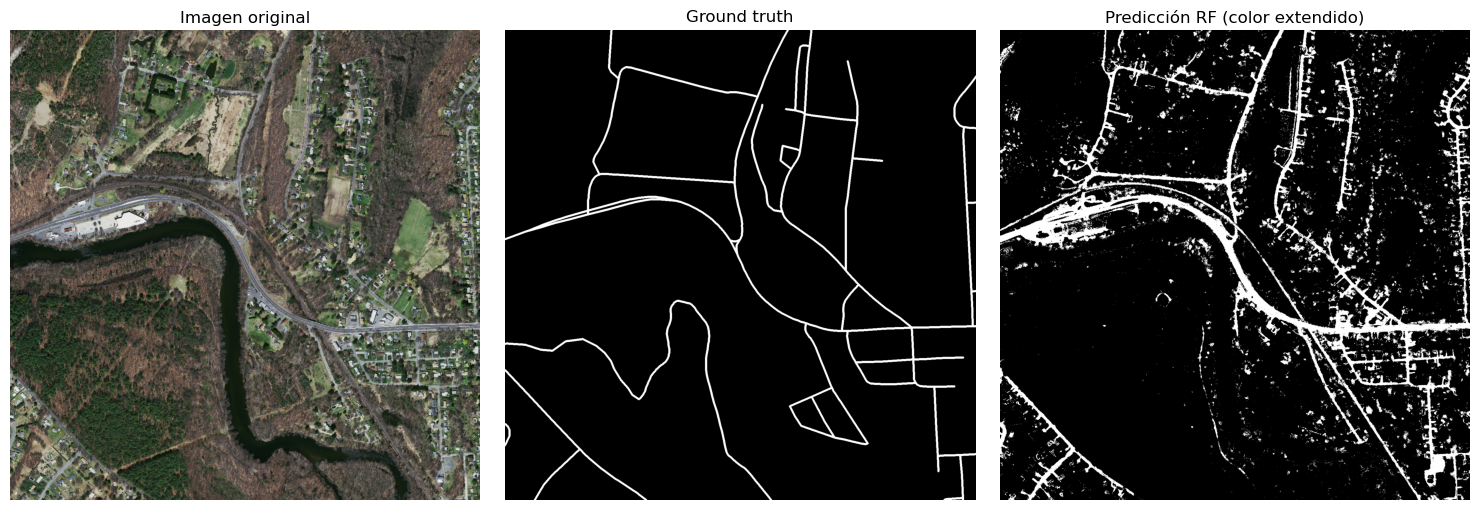

In [ ]:
# RANDOM FOREST
# Definimos el modelo.
rf_col = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=seed, n_jobs=-1, verbose=1)
# Lo entrenamos 
rf_col, y_val_pred_col, y_test_pred_col, metrics_val_col, metrics_test_col = train_and_evaluate_model(rf_col, X_train_col_flat, y_train_col_flat, X_val_col_flat, y_val_col_flat, 
                                                                                                      X_test_col_flat, y_test_col_flat, model_name="RandomForest Color Features")

# Visualizamos 
show_example_prediction(X_val, y_val, y_val_pred_col, title="Predicción RF (color extendido)")

### Postprocesado (le pedi al amigo q me aplicara tu funcion, no me paré para mirar nada pero todo lo anterior yes)

In [118]:
# habria que cambiarlo un poco me parece muy agresivo ??????
def postprocesar_mascara(mascara_pred):
    from skimage.morphology import (binary_opening, binary_closing, 
                                     disk, remove_small_objects, 
                                     remove_small_holes)
    
    mascara = mascara_pred.astype(bool)

    # Paso 1: Opening moderado para eliminar ruido disperso
    mascara = binary_opening(mascara, disk(3))  # Reducido de 4 a 3
    
    # Paso 2: Closing moderado para conectar carreteras cercanas
    mascara = binary_closing(mascara, disk(5))  # Reducido de 8 a 6
    
    # Paso 3: Eliminar objetos pequeños (valor intermedio)
    mascara = remove_small_objects(mascara, min_size=400)  # Reducido de 800 a 400
        
    # Paso 5: Suavizado final ligero
    mascara = binary_opening(mascara, disk(1))  # Reducido de 2 a 1
    
    return mascara.astype(np.uint8)

In [119]:
# Reconvertimos predicciones planas a imágenes
y_val_pred_img = y_val_pred.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])
y_test_pred_img = y_test_pred.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])

y_val_post = np.zeros_like(y_val_pred_img, dtype=np.uint8)
y_test_post = np.zeros_like(y_test_pred_img, dtype=np.uint8)

# Procesar validación
for i in range(X_val.shape[0]):
    y_val_post[i] = postprocesar_mascara(y_val_pred_img[i])

# Procesar test
for i in range(X_test.shape[0]):
    y_test_post[i] = postprocesar_mascara(y_test_pred_img[i])


# EVALUACIÓN

# Aplanar
y_val_post_flat = y_val_post.reshape(-1)
y_test_post_flat = y_test_post.reshape(-1)

print("\n=== VALIDACIÓN (postprocesado) ===")
acc_p  = accuracy_score(y_val_flat,  y_val_post_flat)
prec_p = precision_score(y_val_flat, y_val_post_flat)
rec_p  = recall_score(y_val_flat,   y_val_post_flat)
f1_p   = f1_score(y_val_flat,       y_val_post_flat)

print(f"Accuracy:  {acc_p:.4f}")
print(f"Precision: {prec_p:.4f}")
print(f"Recall:    {rec_p:.4f}")
print(f"F1-Score:  {f1_p:.4f}")


print("\n=== TEST (postprocesado) ===")
acc_tp  = accuracy_score(y_test_flat,  y_test_post_flat)
prec_tp = precision_score(y_test_flat, y_test_post_flat)
rec_tp  = recall_score(y_test_flat,   y_test_post_flat)
f1_tp   = f1_score(y_test_flat,       y_test_post_flat)

print(f"Accuracy:  {acc_tp:.4f}")
print(f"Precision: {prec_tp:.4f}")
print(f"Recall:    {rec_tp:.4f}")
print(f"F1-Score:  {f1_tp:.4f}")


=== VALIDACIÓN (postprocesado) ===
Accuracy:  0.9152
Precision: 0.4025
Recall:    0.7359
F1-Score:  0.5204

=== TEST (postprocesado) ===
Accuracy:  0.8769
Precision: 0.1569
Recall:    0.8260
F1-Score:  0.2638


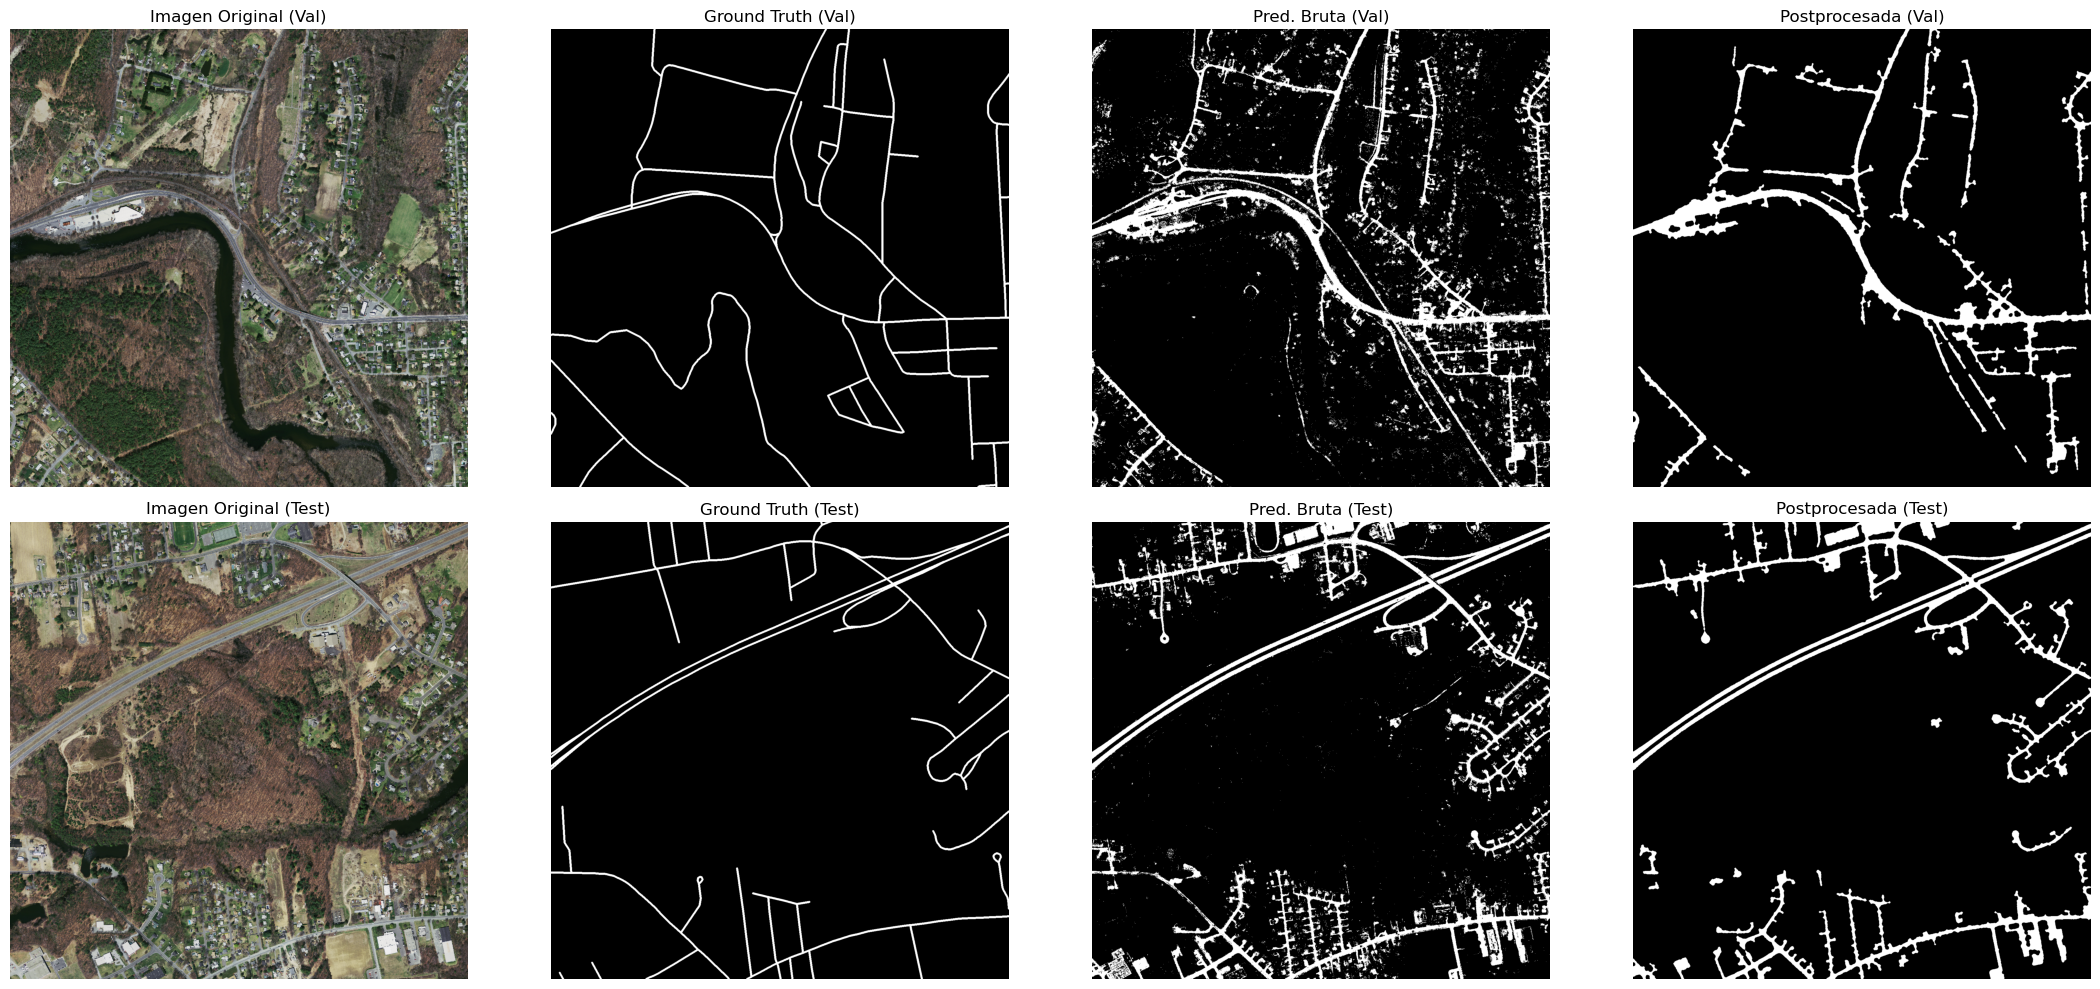

In [120]:

idx_val = 0  # índice de imagen de validación
idx_test = 0 # índice de imagen de test

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# ---- VALIDACIÓN ----
axes[0,0].imshow(X_val[idx_val])
axes[0,0].set_title("Imagen Original (Val)")
axes[0,0].axis('off')

axes[0,1].imshow(y_val[idx_val], cmap='gray')
axes[0,1].set_title("Ground Truth (Val)")
axes[0,1].axis('off')

axes[0,2].imshow(y_val_pred_img[idx_val], cmap='gray')
axes[0,2].set_title("Pred. Bruta (Val)")
axes[0,2].axis('off')

axes[0,3].imshow(y_val_post[idx_val], cmap='gray')
axes[0,3].set_title("Postprocesada (Val)")
axes[0,3].axis('off')


# ---- TEST ----
axes[1,0].imshow(X_test[idx_test])
axes[1,0].set_title("Imagen Original (Test)")
axes[1,0].axis('off')

axes[1,1].imshow(y_test[idx_test], cmap='gray')
axes[1,1].set_title("Ground Truth (Test)")
axes[1,1].axis('off')

axes[1,2].imshow(y_test_pred_img[idx_test], cmap='gray')
axes[1,2].set_title("Pred. Bruta (Test)")
axes[1,2].axis('off')

axes[1,3].imshow(y_test_post[idx_test], cmap='gray')
axes[1,3].set_title("Postprocesada (Test)")
axes[1,3].axis('off')

plt.tight_layout()
plt.show()

